# Row 1 — Linear & Logistic Regression on Crop Recommendation (CG #119)

*ITU AI for Good Sandbox — Training Notebook Series (Row 1 of 10)*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

**What this notebook is.**  A friendly, hands-on walk-through of the two most fundamental supervised-learning models — **Linear Regression** and **Logistic Regression** — using the open **Crop Recommendation** dataset (Kaggle, catalogued in the ITU CG-Datasets TD as **CG #119**).

**Who it is for.**  Complete beginners to machine learning. If you have never trained a model before, you are in the right place.

**How long it takes.**  ~30 minutes end-to-end on Colab free tier.

**How this notebook maps to the curriculum.**
- ITU AI for Good Sandbox Training, **T1: Basic** (Modules 1, 2, 4, 5)
- ITU-T **Y.3172** ML-pipeline nodes: **SRC → PP → M → SINK**
- ITU **AI Readiness Framework** (Report 2.0, §3): **Dimension 1 — Data / Model Marketplace**
- UAE policy anchor: **UAE Open Data Policy (TDRA)** and **National Food Security Strategy 2051**


## 1. What we will build (2.1.1 Model / technique)

Two classical models:

1. **Logistic Regression** — a *classifier*. Given soil and weather readings, it predicts **which of 22 crops** is most suitable to grow. This is our **primary task**.
2. **Linear Regression** — a *regressor*. As a side-exercise, we will predict **rainfall (a continuous value)** from the other columns.

We then add **Ridge** and **Lasso** — regularised variants — and briefly compare with a **Decision Tree** so the next notebook (Row 2) feels natural.

> **Hint — why start here?**  Linear and Logistic Regression are simple, fast, and fully interpretable. They are the *baselines* every ML practitioner tries first. If a fancy model doesn't beat them by a lot, it is not worth the added complexity.


## 2. The dataset & target (2.1.3 Dataset characteristics)

**CG #119 — Crop Recommendation Dataset (Kaggle)**

- ~2,200 rows, class-balanced across 22 crops (~100 samples per crop).
- **7 numeric features**: `N`, `P`, `K` (soil nutrients), `temperature`, `humidity`, `pH`, `rainfall`.
- **1 categorical target**: `label` — the crop name (`rice`, `wheat`, `maize`, `chickpea`, `banana`, …).
- No missing values. Small enough for Colab free tier.

Source: <https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset>

### 2.1 Target type & modelling choice

The target `label` is **categorical (nominal, multi-class)** — there is no natural order between crops.

| Target kind | Model family | Evaluation metrics |
|---|---|---|
| **Categorical** (this notebook's `label`) | **Classifiers** — LogisticRegression, RandomForestClassifier, XGBClassifier | Accuracy, precision / recall, F1, confusion matrix |
| **Continuous** (side-exercise `rainfall`) | **Regressors** — LinearRegression, RandomForestRegressor, XGBRegressor | RMSE, MAE, R² |

### 2.2 Quick way to spot the target type in code
```python
df['label'].dtype        # object / category → categorical
df['label'].nunique()    # 22 → few discrete values, another hint
df['rainfall'].dtype     # float64 → continuous
```


## 3. Setup — install and import libraries

> **Colab tip.**  If you are running locally instead of Colab, ensure `pandas`, `numpy`, `scikit-learn`, `matplotlib` and `seaborn` are installed (`pip install pandas numpy scikit-learn matplotlib seaborn`).


In [5]:
# Colab already has these; the install line is a no-op if already present
!pip install --quiet pandas numpy scikit-learn matplotlib seaborn

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.metrics import root_mean_squared_error
from sklearn.tree import DecisionTreeClassifier


# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
print("Libraries loaded. Ready.")

Libraries loaded. Ready.


## 4. Load the dataset

First download the dataset from https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset The dataset is mirrored on GitHub as a small CSV so it downloads in a second — no Kaggle credentials required.

> **Hint.**  Always print `df.shape` right after loading so you catch a broken download immediately.


In [7]:
DATA_URL = "https://raw.githubusercontent.com/CrashingGuru/Sandbox_Training/main/Dataset/Crop_recommendation.csv"
df = pd.read_csv(DATA_URL)
print("Rows, columns:", df.shape)
df.head()

Rows, columns: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 5. Look at one row (feature vs label)

*Feature* = an input measurement. *Label* = the thing we are trying to predict.

Row 0 reads: **N=90, P=42, K=43, T=20.9 °C, humidity=82 %, pH=6.5, rainfall=203 mm → *rice***. So *rice* likes moist, mildly acidic soil with medium-high nitrogen. This is exactly the pattern the classifier will learn.


In [8]:
row = df.iloc[0]
print(row.to_string())
print("\n→ The label (last column) is what the model tries to predict.")

N                      90
P                      42
K                      43
temperature     20.879744
humidity        82.002744
ph               6.502985
rainfall       202.935536
label                rice

→ The label (last column) is what the model tries to predict.


## 6. Exploratory Data Analysis (EDA)

### 6.1 Shape, dtypes, missing values

> **Hint.**  These three checks catch 80 % of real-world data problems in the first 30 seconds.


In [9]:
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing per column:")
print(df.isna().sum())

Shape: (2200, 8)

Dtypes:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### 6.2 Is the target categorical or continuous?

We can *see* this from the dtype and `nunique()`.


In [10]:
print("label dtype   :", df['label'].dtype, "  →  object => categorical")
print("label nunique :", df['label'].nunique(), "  →  22 discrete classes")
print("rainfall dtype:", df['rainfall'].dtype, "  →  float64 => continuous")

label dtype   : object   →  object => categorical
label nunique : 22   →  22 discrete classes
rainfall dtype: float64   →  float64 => continuous


### 6.3 Class balance

If a class has only 5 samples out of 2,200, accuracy will look great by ignoring it. Let's confirm the dataset is balanced.


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
Name: count, dtype: int64

Min per class: 100 | Max per class: 100


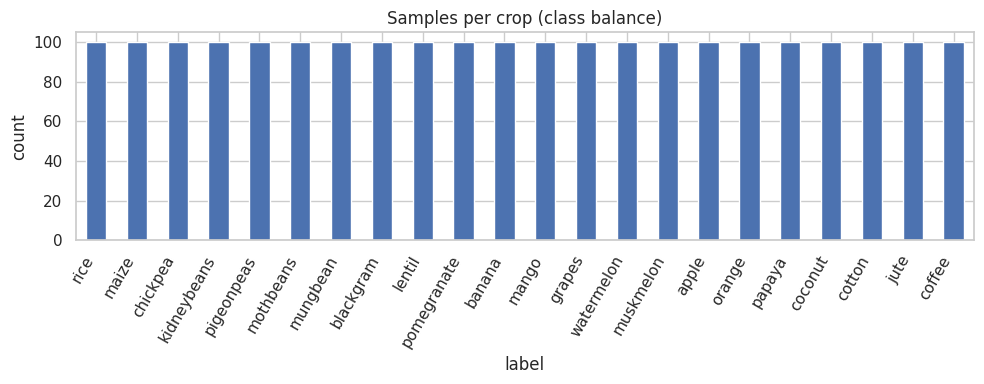

In [11]:
counts = df['label'].value_counts()
print(counts.head())
print("\nMin per class:", counts.min(), "| Max per class:", counts.max())

plt.figure(figsize=(10, 4))
counts.plot(kind='bar')
plt.title("Samples per crop (class balance)")
plt.ylabel("count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Summary statistics — different feature ranges

Notice how `N` ranges 0–140 while `pH` ranges ~3.5–9.9. Different scales → we will need **feature scaling** before logistic regression (Section 8).


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### 6.5 Pairwise scatter (N, P, K) coloured by crop

The three soil-nutrient features already separate several crops fairly well. This is the visual intuition of a *decision boundary*.


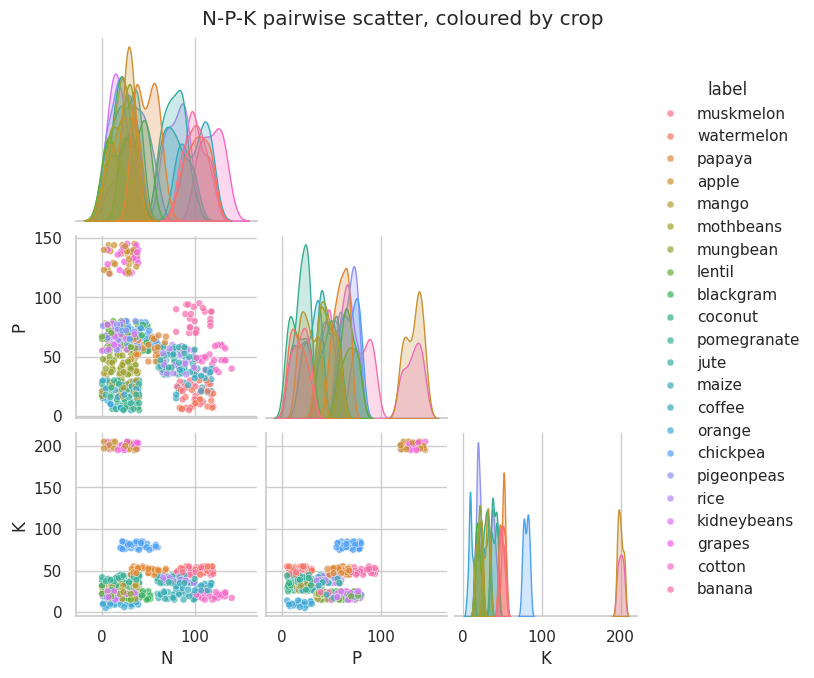

In [13]:
subset = df[['N', 'P', 'K', 'label']].sample(600, random_state=RANDOM_STATE)
sns.pairplot(subset, hue='label', height=2.2, plot_kws={'alpha': 0.7, 's': 25}, corner=True)
plt.suptitle("N-P-K pairwise scatter, coloured by crop", y=1.02)
plt.show()

### 6.6 Correlation heatmap

Correlation between features hints at *collinearity* — a reason to consider Ridge/Lasso later.


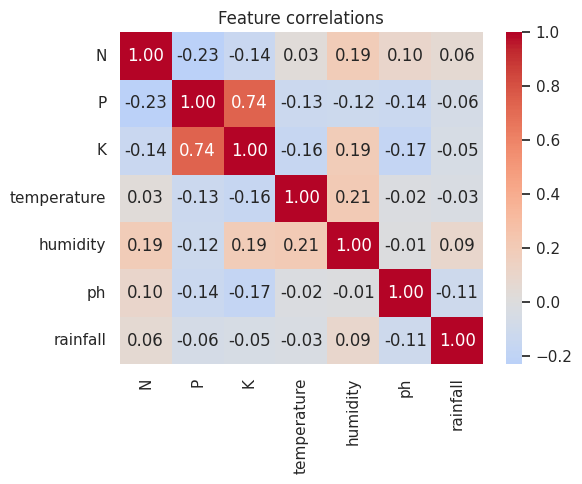

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.drop(columns=['label']).corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations")
plt.tight_layout()
plt.show()

## 7. Train / test split

We keep 80 % of rows for training and 20 % for testing. We use `stratify=y` so that every crop is represented in both splits with the same proportion.

> **Hint.**  `stratify` matters even for balanced datasets — random luck can still skew a small test set.


In [15]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " | Test:", X_test.shape)

Train: (1760, 7)  | Test: (440, 7)


## 8. Feature scaling — StandardScaler

Logistic Regression is sensitive to feature magnitudes. Standardising each column to mean 0 and std 1 lets the optimiser converge faster and makes the coefficients directly comparable.

> **Important.**  Fit the scaler *only on training data*, then apply to both train and test. Fitting on the whole dataset would leak information from the test set.


In [16]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Scaled means (~0):", np.round(X_train_s.mean(axis=0), 2))
print("Scaled stds  (~1):", np.round(X_train_s.std(axis=0), 2))

Scaled means (~0): [ 0.  0.  0. -0. -0. -0.  0.]
Scaled stds  (~1): [1. 1. 1. 1. 1. 1. 1.]


## 9. Fit Logistic Regression (primary — classification task)

`max_iter=1000` gives the optimiser room to converge across 22 classes.


In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)

y_pred = logreg.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.973


### 9.1 Classification report — precision, recall, F1 per class

- **Precision** = of all times we said "wheat", how many were really wheat?
- **Recall** = of all real wheat rows, how many did we catch?
- **F1** = harmonic mean of the two — a single balanced score.


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.95      0.97        20
      papaya       1.00    

### 9.2 Confusion matrix

Rows = true crop, columns = predicted crop. Bright off-diagonal cells are the crops the model confuses.


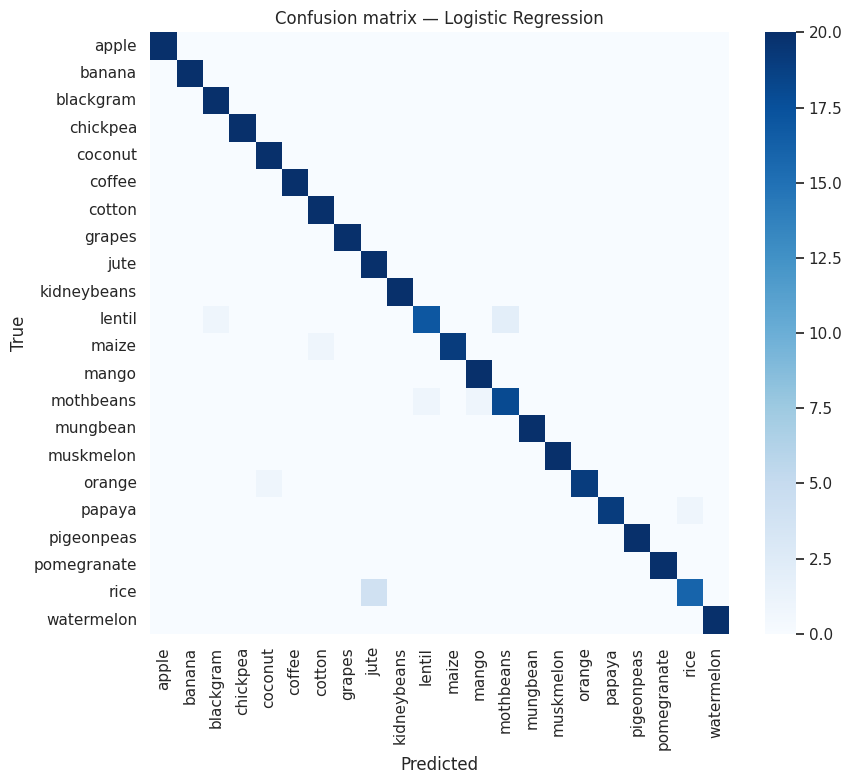

In [19]:
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix — Logistic Regression")
plt.tight_layout()
plt.show()

### 9.3 Cross-validated sanity check

A single train/test split can be lucky or unlucky. **Stratified 5-fold CV** gives a more honest estimate.


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    StandardScaler().fit_transform(X), y, cv=cv, scoring='accuracy'
)
print(f"5-fold CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

5-fold CV accuracy: 0.971 ± 0.002


## 10. Side-exercise — Linear Regression on `rainfall`

This is our **regression** demo. We predict the continuous column `rainfall` from the other six features.


In [21]:
y_reg = df['rainfall']
X_reg = df.drop(columns=['rainfall', 'label'])

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

linreg = LinearRegression().fit(X_reg_tr, y_reg_tr)
y_reg_pred = linreg.predict(X_reg_te)

rmse = mean_squared_error(y_reg_te, y_reg_pred)
mae  = mean_absolute_error(y_reg_te, y_reg_pred)
r2   = r2_score(y_reg_te, y_reg_pred)
print(f"RMSE: {rmse:6.2f}  |  MAE: {mae:6.2f}  |  R²: {r2:.3f}")

RMSE: 2973.05  |  MAE:  41.25  |  R²: 0.012


**Reading the metrics.**
- **RMSE** is in the same units as `rainfall` (mm). It penalises big errors harder than MAE.
- **R²** ranges from 1 (perfect) down through 0 (as good as predicting the mean) to negative (worse than the mean).

Rainfall depends on many things we do not have as features (season, geography, wind), so a modest R² is expected — and honest.


## 11. Read the coefficients — interpretability

Because we scaled the features, we can compare coefficient magnitudes directly. Positive → increases predicted rainfall; negative → decreases it.


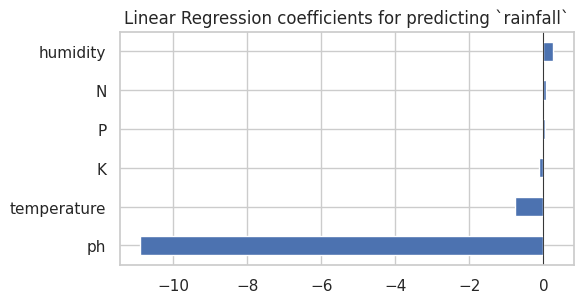

ph            -10.89
temperature    -0.78
K              -0.13
P               0.03
N               0.07
humidity        0.27
dtype: float64


In [22]:
coef = pd.Series(linreg.coef_, index=X_reg.columns).sort_values()

plt.figure(figsize=(6, 3.2))
coef.plot(kind='barh')
plt.title("Linear Regression coefficients for predicting `rainfall`")
plt.axvline(0, color='k', lw=0.6)
plt.tight_layout()
plt.show()

print(coef.round(2))

And for the **classification** model, we can peek at which features drive the *rice* vs *chickpea* decision.


In [23]:
feat = X.columns.tolist()
cls_labels = list(logreg.classes_)

def compare_two_classes(model, class_a, class_b):
    i_a = cls_labels.index(class_a)
    i_b = cls_labels.index(class_b)
    diff = pd.Series(model.coef_[i_a] - model.coef_[i_b], index=feat).sort_values()
    return diff

diff = compare_two_classes(logreg, 'rice', 'chickpea')
print("Coefficient difference (positive → favours rice over chickpea):")
print(diff.round(2))

Coefficient difference (positive → favours rice over chickpea):
K             -2.69
ph            -1.02
P             -0.59
temperature    0.27
N              1.66
humidity       4.50
rainfall       5.77
dtype: float64


## 12. Ridge & Lasso in 3 lines each

**Ridge** shrinks all coefficients toward zero. **Lasso** shrinks *some coefficients exactly to zero* — a form of automatic feature selection. Both help when features are correlated.


In [24]:
ridge = Ridge(alpha=1.0).fit(X_reg_tr, y_reg_tr)
lasso = Lasso(alpha=1.0).fit(X_reg_tr, y_reg_tr)

for name, m in [("Ridge", ridge), ("Lasso", lasso)]:
    p = m.predict(X_reg_te)
    print(f"{name:5s}  RMSE={mean_squared_error(y_reg_te, p):.2f}  "
          f"non-zero coefs={(np.abs(m.coef_) > 1e-6).sum()}/{len(m.coef_)}")

Ridge  RMSE=2972.95  non-zero coefs=6/6
Lasso  RMSE=2959.88  non-zero coefs=6/6


## 13. Motivation for Row 2 — a single Decision Tree

A tiny decision tree gets close to logistic regression on this dataset **without any scaling** — and can capture non-linear patterns. That is why Row 2 goes to Random Forests.


In [25]:
tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)  # note: no scaling needed for trees
print(f"Decision Tree (depth 6) test accuracy: {tree.score(X_test, y_test):.3f}")

Decision Tree (depth 6) test accuracy: 0.570


## 14. Y.3172 pipeline mapping (2.1.4)

The ITU-T Y.3172 recommendation standardises the ML pipeline into named nodes. This notebook exercises the four in bold below.

```
[ SRC ]  →  [  PP  ]  →  [  M  ]  →  [ SINK ]
  ▲             ▲            ▲            ▲
  Kaggle CSV    StandardScaler  LogReg     Crop recommendation
                                / LinReg   (printed / dashboard)
```

- **SRC (Source of data)** — the mirrored Kaggle CSV.
- **PP (Pre-processor)** — `StandardScaler` fit on train only.
- **M (Model)** — Logistic Regression (primary), Linear Regression (side).
- **SINK** — for a real deployment, the predicted crop would be shown to the farmer via app or SMS.

> Node **C (Collector)**, **P (Policy)** and **D (Distributor)** are not exercised here — they appear in later rows (see Row 2 for **P**, Row 9 for **D**).


## 15. AI Readiness dimension & applicable UAE policy (2.1.7, 2.1.8)

**AI Readiness Framework (Report 2.0, §3) — Dimension 1: Data / Model Marketplace.**
The dataset is a machine-readable CSV with clear metadata and a permissive licence — exactly the "open, reusable dataset with rich metadata" that Dimension 1 is measuring.

**Applicable UAE policies (specific clauses):**

| Policy / strategy | Specific clause | How this notebook is aligned |
|---|---|---|
| **UAE Open Data Policy (TDRA, Federal)** | Open-by-default publication, **machine-readable formats (CSV/JSON)**, reuse licence | CSV format + permissive licence — meets all three |
| **National Food Security Strategy 2051** | Pillar 2 — *"Enable technology-based production of food"*; KPI on precision-agriculture adoption | Precision recommendation is exactly this KPI in miniature |
| **National AI Strategy 2031** | Government axis — data availability for priority sectors including food & agriculture | Notebook uses an open sectoral dataset end-to-end |

> **Discussion prompt for participants.** Which of the 7 input features would need extra governance if collected from real UAE farms (e.g. GPS-tagged soil test)? Which UAE regulator would you notify? *(Hint: PDPL if the farmer's identity is derivable; TDRA for open-data publication.)*


## 16. Further reading & references (2.1.5, 2.1.6, 2.1.9)

**Discovery Series webinars (aiforgood.itu.int/eventcat/webinar/)**
- *Introduction to ML for Networks*
- *Innovate for Impact 2024* — see the Agmarknet / Open Data Telangana use-case (CG #86)

**Related ITU AI/ML Challenges (aiforgood.itu.int/ai-ml-challenges/)**
- ITU AI/ML 2024 Challenge on Weather Stations — CG #1
- Innovate for Impact 2024 — Agmarknet (CG #86)

**Papers**
- ITU Kaleidoscope 2017 proceedings (rural ICT / precision agriculture): <https://www.itu.int/en/publications/Documents/tsb/2017-ITU-Kaleidoscope/index.html>
- *Precision Agriculture Revolution: Integrating Digital Twins and Advanced Crop Recommendation for Optimal Yield* — arXiv:2502.04054 — uses the same NPK+weather feature set with tabular ML.

**ITU AI Readiness Framework 2.0 (Jan 2026)** — Report §3, Dimension 1 "Data/Model Marketplace".

**Y.3172** — Recommendation ITU-T Y.3172: *Architectural framework for machine learning in future networks including IMT-2020*.


## 17. Wrap-up & what's next

✅ You just:
1. Loaded an open dataset with a **categorical target**.
2. Ran full **EDA** — shape, dtypes, missing values, class balance, correlations, pairwise scatter.
3. Trained **Logistic Regression** and evaluated it with **accuracy + classification report + confusion matrix + 5-fold CV**.
4. Ran a **Linear Regression** side-exercise with **RMSE / MAE / R²**.
5. Interpreted the model via **coefficients**.
6. Peeked at **Ridge & Lasso** and a single **Decision Tree**.
7. Mapped everything to **Y.3172**, **AI Readiness Dimension 1**, and **UAE Open Data / NFSS 2051** clauses.

**Next notebook — Row 2:**
Decision Trees & Random Forest on the **QoS Prediction** dataset (CG #16). You'll reuse the train/test/scale workflow, add feature-importance and SHAP, and see a *continuous* target with regression metrics.

---

*ITU AI for Good Sandbox Training Notebook — Row 1 of 10.*
